In [46]:
print("Hey there")

Hey there


In [47]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

#  define state
class BMIState(TypedDict):
    height_m: float
    weight_kg: float
    bmi: float
    category: str

In [48]:
#  make function
def bmi_calc(state: BMIState)-> BMIState:
    weight = state["weight_kg"]
    height = state["height_m"]
    bmi = weight/height**2
    state['bmi'] = round(bmi, 2)
    return state

In [49]:
def level_bmi(state: BMIState)-> BMIState:
    bmi = state['bmi']
    if(bmi<18.5):
        state['category'] = 'Underweight'
    elif(18.5 <=bmi <25):
        state['bmi'] = 'Normal'
    elif(25 <=bmi <30):
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obese'
    return state

In [53]:
graph = StateGraph(BMIState)

#  add nodes
graph.add_node("calculate_bmi", bmi_calc)

graph.add_node('level_bmi', level_bmi)

graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'level_bmi')
graph.add_edge('level_bmi', END)


In [54]:
#  compile the graph
workflow = graph.compile()

In [55]:
#  execute the graph

initial_state= {'weight_kg':65, 'height_m':2}

final_state = workflow.invoke(initial_state)

print(final_state)

{'height_m': 2, 'weight_kg': 65, 'bmi': 16.25, 'category': 'Underweight'}


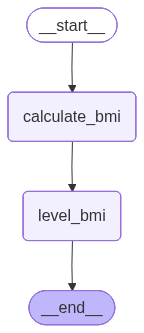

In [56]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))